# 09 — Portfolio Optimization walk-forward

Notebook ini membandingkan tiga allocator PyPortfolioOpt: Mean-Variance Max Sharpe, Minimum Volatility, dan Risk Parity/HRP. Parameter estimasi hanya memakai rolling window tiga tahun terakhir (756 hari perdagangan), lalu bobot dihitung pada penutupan akhir tahun dan baru digunakan mulai hari perdagangan berikutnya.

Constraint utama: long-only dan bobot maksimum 20% per saham. Hasil out-of-sample dibandingkan dengan equal-weight 15 saham dan LQ45. Return strategi memakai close-to-close adjusted price dan belum memasukkan biaya transaksi.

In [1]:
from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster import hierarchy as scipy_hierarchy

try:
    from pypfopt import EfficientFrontier, HRPOpt, expected_returns, risk_models
except ImportError as exc:
    raise ImportError('Install PyPortfolioOpt dengan: pip install PyPortfolioOpt') from exc

# Compatibility shim: older PyPortfolioOpt versions expect this private
# SciPy attribute, which is absent in newer SciPy releases. The HRP
# algorithm still uses scipy_hierarchy.linkage normally after validation.
if not hasattr(scipy_hierarchy, '_LINKAGE_METHODS'):
    scipy_hierarchy._LINKAGE_METHODS = {
        'single', 'complete', 'average', 'weighted',
        'centroid', 'median', 'ward',
    }

warnings.filterwarnings('ignore', category=FutureWarning)
ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent

LOOKBACK_DAYS = 3 * 252
MAX_WEIGHT = 0.20
TRADING_DAYS_PER_YEAR = 252
INITIAL_CAPITAL = 1.0
print(f'Project root: {ROOT}')

Project root: D:\7. PROYEK\5. BACKTEST & OPTIMIZE\Ori_Data


## Load data dan kalender rebalance

Tanggal akhir tahun dipakai sebagai tanggal pembentukan sinyal. Karena sinyal dibentuk pada penutupan tanggal tersebut, return out-of-sample dimulai pada baris berikutnya.

In [2]:
master = pd.read_parquet(ROOT / 'data' / 'processed' / 'master_daily.parquet')
master['date'] = pd.to_datetime(master['date'])
master = master.sort_values('date').set_index('date')
stocks = [c for c in master.columns if str(c).endswith('.JK')]
assert len(stocks) == 15
prices = master[stocks].apply(pd.to_numeric, errors='coerce')
lq45 = pd.to_numeric(master['lq45'], errors='coerce')
bi_rate_annual = pd.to_numeric(master['bi_rate'], errors='coerce').ffill() / 100.0
assert prices.index.is_monotonic_increasing and not prices.index.duplicated().any()
assert prices.notna().all().all() and (prices > 0).all().all()
assert lq45.notna().all() and bi_rate_annual.notna().all()

year_end_dates = prices.groupby(prices.index.year).apply(lambda frame: frame.index[-1])
rebalance_dates = [
    pd.Timestamp(date) for date in year_end_dates
    if prices.index.get_loc(pd.Timestamp(date)) >= LOOKBACK_DAYS
    and prices.index.get_loc(pd.Timestamp(date)) + 1 < len(prices)
]
print(f'Periode: {prices.index.min().date()} s.d. {prices.index.max().date()}')
print('Tanggal rebalance:', [d.date() for d in rebalance_dates])

Periode: 2016-09-22 s.d. 2026-09-21
Tanggal rebalance: [datetime.date(2019, 12, 30), datetime.date(2020, 12, 30), datetime.date(2021, 12, 30), datetime.date(2022, 12, 30), datetime.date(2023, 12, 29), datetime.date(2024, 12, 30), datetime.date(2025, 12, 30)]


## Helper optimizer dan constraint bobot

Mean-Variance memakai `weight_bounds=(0, 0.20)`. HRP tidak menyediakan upper bound langsung pada semua versi PyPortfolioOpt, sehingga hasil HRP diproyeksikan ulang ke bobot non-negatif yang jumlahnya satu dan setiap bobot maksimal 20%. Proyeksi ini dilakukan setiap tanggal rebalance.

In [3]:
def cap_weights(weights, upper=MAX_WEIGHT):
    """Project non-negative weights to sum 1 with an upper bound."""
    w = pd.Series(weights, dtype=float).fillna(0.0).clip(lower=0.0)
    if w.sum() <= 0:
        w[:] = 1.0 / len(w)
    else:
        w /= w.sum()
    if len(w) * upper < 1.0 - 1e-12:
        raise ValueError('Constraint upper bound tidak feasible.')

    for _ in range(len(w) + 2):
        over = w > upper + 1e-12
        if not over.any():
            break
        excess = float((w[over] - upper).sum())
        w[over] = upper
        free = ~over
        if not free.any():
            raise ValueError('Tidak ada bobot bebas untuk redistribusi excess.')
        free_sum = w[free].sum()
        if free_sum <= 0:
            w[free] += excess / free.sum()
        else:
            w[free] += excess * w[free] / free_sum
    w = w / w.sum()
    assert abs(w.sum() - 1.0) < 1e-10
    assert (w >= -1e-10).all() and (w <= upper + 1e-10).all()
    return w

def estimate_inputs(price_window):
    returns_window = price_window.pct_change().dropna(how='any')
    mu = expected_returns.mean_historical_return(price_window, frequency=TRADING_DAYS_PER_YEAR)
    covariance = risk_models.sample_cov(price_window, frequency=TRADING_DAYS_PER_YEAR)
    covariance = risk_models.fix_nonpositive_semidefinite(covariance)
    return mu, covariance, returns_window

def optimize_one_window(price_window, risk_free_rate):
    mu, covariance, returns_window = estimate_inputs(price_window)
    bounds = (0.0, MAX_WEIGHT)

    max_sharpe_ef = EfficientFrontier(mu, covariance, weight_bounds=bounds)
    max_sharpe_ef.max_sharpe(risk_free_rate=float(risk_free_rate))
    max_sharpe = pd.Series(max_sharpe_ef.clean_weights()).reindex(stocks).fillna(0.0)

    min_vol_ef = EfficientFrontier(mu, covariance, weight_bounds=bounds)
    min_vol_ef.min_volatility()
    min_vol = pd.Series(min_vol_ef.clean_weights()).reindex(stocks).fillna(0.0)

    hrp = HRPOpt(returns=returns_window, cov_matrix=covariance)
    hrp_raw = pd.Series(hrp.optimize()).reindex(stocks).fillna(0.0)
    hrp_capped = cap_weights(hrp_raw)

    result = pd.DataFrame({
        'max_sharpe': cap_weights(max_sharpe),
        'min_volatility': cap_weights(min_vol),
        'hrp': hrp_capped,
    })
    assert (result >= -1e-10).all().all()
    assert (result <= MAX_WEIGHT + 1e-10).all().all()
    assert np.allclose(result.sum(axis=0), 1.0, atol=1e-8)
    return result, mu, covariance, returns_window


## Walk-forward optimization

Setiap model hanya melihat `LOOKBACK_DAYS` observasi sampai tanggal rebalance. Bobot pada tanggal rebalance belum digunakan untuk return hari tersebut; bobot baru aktif mulai hari perdagangan berikutnya.

In [4]:
weights_by_period = {}
diagnostic_rows = []
for rebalance_date in rebalance_dates:
    price_window = prices.loc[:rebalance_date].tail(LOOKBACK_DAYS + 1)
    assert len(price_window) == LOOKBACK_DAYS + 1
    period_weights, mu, covariance, returns_window = optimize_one_window(
        price_window, bi_rate_annual.loc[rebalance_date]
    )
    weights_by_period[rebalance_date] = period_weights
    diagnostic_rows.append({
        'rebalance_date': rebalance_date,
        'window_start': price_window.index[0],
        'window_end': price_window.index[-1],
        'observations': len(returns_window),
        'risk_free_rate': bi_rate_annual.loc[rebalance_date],
    })

portfolio_methods = list(next(iter(weights_by_period.values())).columns)
method_tables = {
    method: pd.DataFrame({
        date: weights_by_period[date][method].reindex(stocks)
        for date in weights_by_period
    }).T.reindex(columns=stocks)
    for method in portfolio_methods
}
weights_period = pd.concat(method_tables, axis=1)
weights_period.columns.names = ['method', 'ticker']
diagnostics = pd.DataFrame(diagnostic_rows)
assert weights_period.index.is_monotonic_increasing
print(diagnostics.to_string(index=False))
weights_period.round(4)

rebalance_date window_start window_end  observations  risk_free_rate
    2019-12-30   2016-11-14 2019-12-30           756          0.0500
    2020-12-30   2017-11-16 2020-12-30           756          0.0375
    2021-12-30   2018-11-26 2021-12-30           756          0.0350
    2022-12-30   2019-11-27 2022-12-30           756          0.0550
    2023-12-29   2020-11-23 2023-12-29           756          0.0600
    2024-12-30   2021-11-12 2024-12-30           756          0.0600
    2025-12-30   2022-10-31 2025-12-30           756          0.0475


method     max_sharpe                                                          \
ticker        BBCA.JK BBRI.JK BMRI.JK BBNI.JK TLKM.JK EXCL.JK ASII.JK UNTR.JK   
2019-12-30     0.2000  0.2000  0.1327  0.1914   0.000  0.0165     0.0  0.0000   
2020-12-30     0.2000  0.2000  0.0000  0.0000   0.000  0.0000     0.0  0.0000   
2021-12-30     0.2000  0.2000  0.0000  0.0000   0.000  0.1770     0.0  0.0000   
2022-12-30     0.2000  0.0000  0.0970  0.0000   0.000  0.0000     0.0  0.0000   
2023-12-29     0.1278  0.1662  0.2000  0.2000   0.077  0.0000     0.0  0.0000   
2024-12-30     0.0816  0.0000  0.2000  0.0000   0.000  0.0000     0.0  0.0748   
2025-12-30     0.0000  0.0000  0.0117  0.0000   0.000  0.2000     0.2  0.2000   

method                      ...     hrp                                  \
ticker     UNVR.JK ICBP.JK  ... EXCL.JK ASII.JK UNTR.JK UNVR.JK ICBP.JK   
2019-12-30     0.0  0.2000  ...  0.0420  0.0870  0.0480  0.0954  0.0852   
2020-12-30     0.0  0.2000  ...  0.0332  0.0630  0.0599  0.1048  0.1177   
2021-12-30     0.0  0.0000  ...  0.0446  0.0690  0.0594  0.0908  0.0937   
2022-12-30     0.0  0.0000  ...  0.0483  0.0699  0.0616  0.0790  0.0943   
2023-12-29     0.0  0.0076  ...  0.0446  0.0711  0.0394  0.0656  0.1039   
2024-12-30     0.0  0.1040  ...  0.0629  0.0796  0.0703  0.0558  0.0947   
2025-12-30     0.0  0.0000  ...  0.0876  0.0677  0.0495  0.0534  0.0800   

method                                              
ticker     INDF.JK KLBF.JK ANTM.JK PTBA.JK ITMG.JK  
2019-12-30  0.0680  0.0583  0.0536  0.0518  0.0381  
2020-12-30  0.0761  0.0883  0.0566  0.0488  0.0573  
2021-12-30  0.0687  0.1136  0.0322  0.0444  0.0403  
2022-12-30  0.0819  0.1123  0.0326  0.0425  0.0378  
2023-12-29  0.1714  0.0853  0.0333  0.0373  0.0354  
2024-12-30  0.1545  0.0797  0.0508  0.0330  0.0349  
2025-12-30  0.0995  0.0502  0.0570  0.0511  0.0926  

[7 rows x 45 columns]

## Bobot tiap periode

Tabel berikut menunjukkan bobot 15 saham pada setiap akhir tahun. Baris tersebut adalah tanggal pembentukan sinyal; implementasi harian di bawah menggesernya satu hari perdagangan untuk eksekusi.

In [5]:
for method in portfolio_methods:
    print(f'\n{method}')
    display(weights_period[method].style.format('{:.2%}').background_gradient(cmap='Blues', axis=1))


max_sharpe


ticker,BBCA.JK,BBRI.JK,BMRI.JK,BBNI.JK,TLKM.JK,EXCL.JK,ASII.JK,UNTR.JK,UNVR.JK,ICBP.JK,INDF.JK,KLBF.JK,ANTM.JK,PTBA.JK,ITMG.JK
2019-12-30 00:00:00,20.00%,20.00%,13.27%,19.14%,0.00%,1.65%,0.00%,0.00%,0.00%,20.00%,0.00%,0.00%,0.00%,5.95%,0.00%
2020-12-30 00:00:00,20.00%,20.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,20.00%,0.00%,0.00%,20.00%,20.00%,0.00%
2021-12-30 00:00:00,20.00%,20.00%,0.00%,0.00%,0.00%,17.70%,0.00%,0.00%,0.00%,0.00%,5.66%,0.00%,20.00%,0.00%,16.64%
2022-12-30 00:00:00,20.00%,0.00%,9.71%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,19.38%,20.00%,10.91%,20.00%
2023-12-29 00:00:00,12.78%,16.62%,20.00%,20.00%,7.70%,0.00%,0.00%,0.00%,0.00%,0.76%,0.00%,0.00%,0.00%,2.14%,20.00%
2024-12-30 00:00:00,8.16%,0.00%,20.00%,0.00%,0.00%,0.00%,0.00%,7.48%,0.00%,10.40%,20.00%,0.00%,0.00%,13.97%,20.00%
2025-12-30 00:00:00,0.00%,0.00%,1.17%,0.00%,0.00%,20.00%,20.00%,20.00%,0.00%,0.00%,18.83%,0.00%,20.00%,0.00%,0.00%



min_volatility


ticker,BBCA.JK,BBRI.JK,BMRI.JK,BBNI.JK,TLKM.JK,EXCL.JK,ASII.JK,UNTR.JK,UNVR.JK,ICBP.JK,INDF.JK,KLBF.JK,ANTM.JK,PTBA.JK,ITMG.JK
2019-12-30 00:00:00,20.00%,1.78%,0.00%,2.58%,10.16%,0.61%,5.94%,0.10%,18.11%,20.00%,4.12%,2.52%,4.00%,6.02%,4.05%
2020-12-30 00:00:00,20.00%,0.00%,0.00%,0.00%,12.71%,0.00%,6.45%,2.01%,19.30%,20.00%,3.26%,9.55%,0.00%,0.98%,5.73%
2021-12-30 00:00:00,20.00%,0.75%,0.00%,0.00%,15.47%,0.00%,3.59%,1.70%,14.57%,20.00%,3.60%,13.59%,0.00%,0.00%,6.72%
2022-12-30 00:00:00,20.00%,0.00%,0.00%,0.00%,15.38%,0.00%,4.26%,2.82%,9.21%,20.00%,9.23%,12.10%,0.00%,0.00%,7.01%
2023-12-29 00:00:00,16.48%,6.42%,1.14%,0.00%,11.83%,2.69%,5.79%,2.39%,6.07%,12.44%,20.00%,6.54%,1.44%,0.22%,6.54%
2024-12-30 00:00:00,16.19%,2.76%,0.00%,0.00%,10.50%,4.89%,5.14%,4.21%,5.88%,10.38%,20.00%,6.17%,6.22%,0.00%,7.65%
2025-12-30 00:00:00,16.39%,0.00%,0.00%,0.00%,4.95%,9.66%,10.04%,1.58%,1.94%,14.02%,17.32%,4.03%,3.22%,1.47%,15.37%



hrp


ticker,BBCA.JK,BBRI.JK,BMRI.JK,BBNI.JK,TLKM.JK,EXCL.JK,ASII.JK,UNTR.JK,UNVR.JK,ICBP.JK,INDF.JK,KLBF.JK,ANTM.JK,PTBA.JK,ITMG.JK
2019-12-30 00:00:00,12.46%,5.05%,4.85%,5.44%,9.45%,4.20%,8.70%,4.80%,9.54%,8.52%,6.80%,5.83%,5.36%,5.18%,3.81%
2020-12-30 00:00:00,9.48%,4.62%,3.98%,3.71%,7.63%,3.32%,6.30%,5.99%,10.48%,11.77%,7.61%,8.83%,5.66%,4.88%,5.73%
2021-12-30 00:00:00,12.52%,4.74%,4.57%,5.12%,7.37%,4.46%,6.90%,5.94%,9.08%,9.37%,6.87%,11.36%,3.22%,4.44%,4.03%
2022-12-30 00:00:00,11.54%,4.82%,4.75%,5.29%,7.57%,4.83%,6.99%,6.16%,7.90%,9.43%,8.19%,11.23%,3.26%,4.25%,3.78%
2023-12-29 00:00:00,8.11%,5.52%,4.88%,4.52%,8.27%,4.46%,7.11%,3.94%,6.56%,10.39%,17.14%,8.53%,3.33%,3.73%,3.54%
2024-12-30 00:00:00,7.16%,4.65%,4.33%,4.19%,8.05%,6.29%,7.96%,7.03%,5.58%,9.47%,15.45%,7.97%,5.08%,3.30%,3.49%
2025-12-30 00:00:00,8.51%,4.30%,3.99%,6.91%,7.43%,8.76%,6.77%,4.95%,5.34%,8.00%,9.95%,5.02%,5.70%,5.11%,9.26%


## Equity curve out-of-sample

Return portofolio pada tanggal `d` memakai bobot yang dibentuk pada tanggal sebelumnya. Dengan demikian, tidak ada penggunaan bobot baru untuk return yang terjadi sebelum eksekusi. Equal-weight adalah equal-weight harian tanpa biaya transaksi; LQ45 adalah total return berbasis adjusted close index.

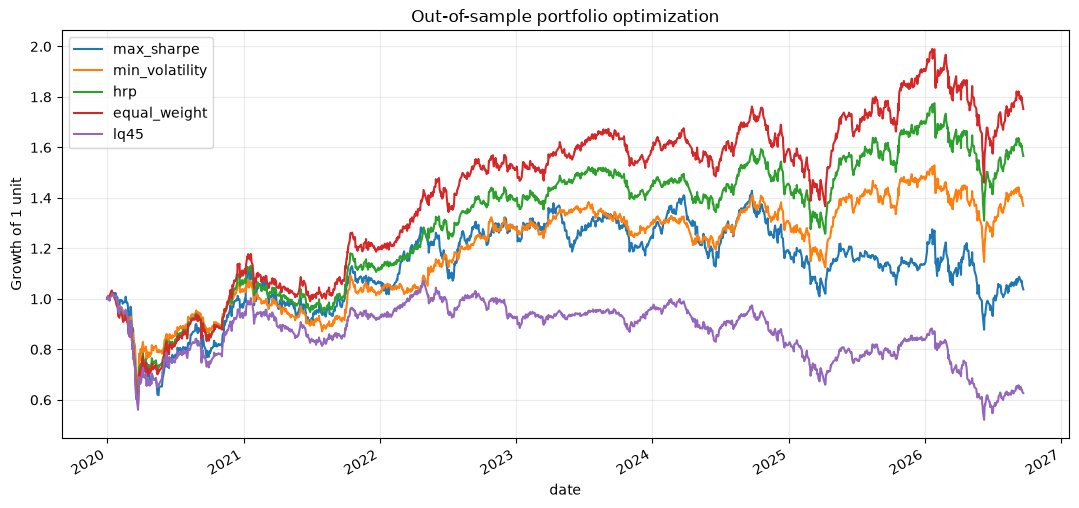

In [6]:
asset_returns = prices.pct_change()
signal_schedule = {method: pd.DataFrame(np.nan, index=prices.index, columns=stocks) for method in portfolio_methods}
for rebalance_date in weights_period.index:
    for method in signal_schedule:
        signal_schedule[method].loc[rebalance_date] = weights_period.loc[rebalance_date, method].to_numpy()

strategy_returns = {}
holding_weights = {}
for method, schedule in signal_schedule.items():
    # Shift makes a close-at-t signal active for the next trading day.
    held = schedule.ffill().shift(1)
    daily_returns = (held * asset_returns).sum(axis=1, min_count=len(stocks))
    valid = held.notna().all(axis=1) & daily_returns.notna()
    holding_weights[method] = held.loc[valid]
    strategy_returns[method] = daily_returns.loc[valid]

common_dates = strategy_returns['max_sharpe'].index
strategy_returns['equal_weight'] = asset_returns.loc[common_dates, stocks].mean(axis=1)
strategy_returns['lq45'] = lq45.loc[common_dates].pct_change().fillna(0.0)
returns_oos = pd.DataFrame(strategy_returns).dropna(how='any')
equity_oos = INITIAL_CAPITAL * (1.0 + returns_oos).cumprod()
equity_oos.plot(figsize=(13, 6), title='Out-of-sample portfolio optimization')
plt.ylabel('Growth of 1 unit')
plt.grid(alpha=0.25)
plt.show()

## Performance comparison

Sharpe menggunakan BI Rate harian yang diturunkan dari `master_daily['bi_rate']`. Turnover belum dihitung sebagai pengurang return di notebook ini; gunakan `src/backtester.py` untuk simulasi biaya broker dan slippage.

In [7]:
def performance_metrics(returns, equity, risk_free_daily):
    returns = returns.dropna()
    rf = risk_free_daily.reindex(returns.index).dropna()
    aligned = returns.reindex(rf.index)
    years = len(equity) / TRADING_DAYS_PER_YEAR
    cagr = float((equity.iloc[-1] / equity.iloc[0]) ** (1 / years) - 1)
    volatility = float(aligned.std(ddof=1) * np.sqrt(TRADING_DAYS_PER_YEAR))
    excess = aligned - rf
    sharpe = float(excess.mean() / excess.std(ddof=1) * np.sqrt(TRADING_DAYS_PER_YEAR))
    downside = np.minimum(excess.to_numpy(), 0.0)
    downside_dev = np.sqrt(np.mean(downside ** 2))
    sortino = float(excess.mean() / downside_dev * np.sqrt(TRADING_DAYS_PER_YEAR)) if downside_dev > 0 else np.nan
    drawdown = equity / equity.cummax() - 1.0
    max_dd = float(drawdown.min())
    return {
        'CAGR': cagr, 'volatility_annual': volatility, 'Sharpe': sharpe,
        'Sortino': sortino, 'Max Drawdown': max_dd,
        'Calmar': cagr / abs(max_dd) if max_dd < 0 else np.nan,
        'win_rate': float((aligned > 0).mean()),
    }

risk_free_daily = (1.0 + bi_rate_annual.loc[returns_oos.index]).pow(1 / TRADING_DAYS_PER_YEAR) - 1.0
metrics = pd.DataFrame({
    name: performance_metrics(returns_oos[name], equity_oos[name], risk_free_daily)
    for name in returns_oos.columns
}).T
metrics.style.format({
    'CAGR': '{:.2%}', 'volatility_annual': '{:.2%}', 'Sharpe': '{:.2f}',
    'Sortino': '{:.2f}', 'Max Drawdown': '{:.2%}', 'Calmar': '{:.2f}',
    'win_rate': '{:.2%}',
})

,CAGR,volatility_annual,Sharpe,Sortino,Max Drawdown,Calmar,win_rate
max_sharpe,0.58%,24.61%,-0.05,-0.07,-42.65%,0.01,49.57%
min_volatility,5.01%,19.52%,0.11,0.15,-37.26%,0.13,50.12%
hrp,7.24%,20.22%,0.21,0.31,-42.09%,0.17,51.36%
equal_weight,9.14%,21.03%,0.30,0.43,-43.98%,0.21,51.61%
lq45,-7.02%,22.43%,-0.42,-0.59,-51.44%,-0.14,49.81%


## Efficient frontier

Frontier ditampilkan untuk jendela estimasi terakhir yang tersedia. Titik Max Sharpe dan Minimum Volatility menggunakan constraint yang sama, yaitu long-only dan maksimum 20% per saham.

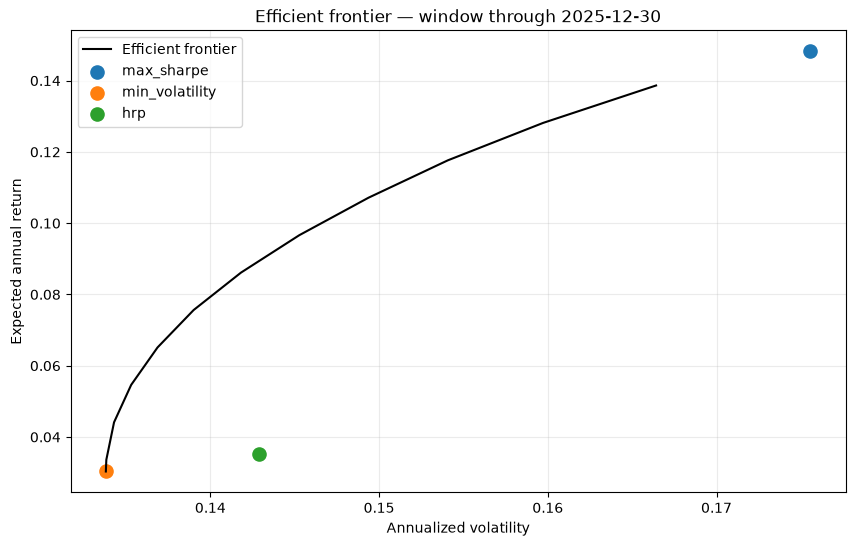

In [8]:
frontier_date = rebalance_dates[-1]
frontier_prices = prices.loc[:frontier_date].tail(LOOKBACK_DAYS + 1)
frontier_mu, frontier_cov, _ = estimate_inputs(frontier_prices)

def portfolio_point(weights, mu, covariance):
    w = np.asarray(weights, dtype=float)
    expected = float(np.dot(w, mu.to_numpy()))
    volatility = float(np.sqrt(np.dot(w, np.dot(covariance.to_numpy(), w))))
    return volatility, expected

frontier_rows = []
low_return = float(frontier_mu.min())
high_return = float(frontier_mu.max())
for target_return in np.linspace(low_return, high_return, 40):
    try:
        ef = EfficientFrontier(frontier_mu, frontier_cov, weight_bounds=(0, MAX_WEIGHT))
        ef.efficient_return(target_return)
        w = pd.Series(ef.clean_weights()).reindex(stocks).fillna(0.0)
        volatility, expected = portfolio_point(w, frontier_mu, frontier_cov)
        frontier_rows.append({'volatility': volatility, 'return': expected})
    except Exception:
        continue
frontier = pd.DataFrame(frontier_rows)

last_weights = weights_period.loc[frontier_date]
points = {}
for method in ['max_sharpe', 'min_volatility', 'hrp']:
    points[method] = portfolio_point(last_weights[method], frontier_mu, frontier_cov)

plt.figure(figsize=(10, 6))
plt.plot(frontier['volatility'], frontier['return'], label='Efficient frontier', color='black')
for method, (volatility, expected) in points.items():
    plt.scatter(volatility, expected, s=90, label=method)
plt.xlabel('Annualized volatility')
plt.ylabel('Expected annual return')
plt.title(f'Efficient frontier — window through {frontier_date.date()}')
plt.legend()
plt.grid(alpha=0.25)
plt.show()

In [9]:
reports_dir = ROOT / 'reports'
reports_dir.mkdir(parents=True, exist_ok=True)
processed_dir = ROOT / 'data' / 'processed'
weights_period.to_csv(reports_dir / 'portfolio_optimization_weights.csv')
weights_period.to_csv(processed_dir / 'portfolio_optimization_weights.csv')
metrics.to_csv(reports_dir / 'portfolio_optimization_performance.csv')
metrics.to_csv(processed_dir / 'portfolio_optimization_performance.csv')
equity_oos.to_csv(ROOT / 'data' / 'processed' / 'portfolio_optimization_equity.csv')
diagnostics.to_csv(reports_dir / 'portfolio_optimization_windows.csv', index=False)
diagnostics.to_csv(processed_dir / 'portfolio_optimization_windows.csv', index=False)
print('Artefak portfolio optimization tersimpan di reports/.')

Artefak portfolio optimization tersimpan di reports/.


## Catatan interpretasi

Perbandingan di atas murni out-of-sample terhadap data yang tersedia setelah setiap rebalance. Hasil tidak boleh dibaca sebagai performa historis yang dapat diketahui sebelum tanggal rebalance. Untuk penggunaan produksi, gabungkan bobot tahunan ini dengan `src/backtester.py` agar fee beli/jual, slippage, dan turnover aktual ikut diperhitungkan.